In [1]:
import numpy as np
import matplotlib.pyplot as plt

from imagematerials.rest_of.resource_model import ResourceModel
from imagematerials.rest_of.const import (COPPER_AVERAGE_REGIONS_TO_IMAGE, 
                                          all_regions_list_class,
                                          models_output_dict)

In [2]:
# COPPER
copper = ResourceModel(resource_group = 'metals', resource = 'copper', 
                       image_mat_available = True, start_year = 1990,
                       scenario= 'SSP2_M_CP', end_year = 2011)

class_1 = ['class_ 1'] 

low_steady = ['class_ 3', 'class_ 13']
high_gdp_low = ['class_ 2', 'class_ 11']
medium_steady = ['class_ 12', 'class_ 16']
high_steady = ['class_ 10', 'class_ 15', 'class_ 19', 'class_ 20', 'class_ 23']


# what is in rest will not be fitted because of outliers - will follow global projections       
rest = all_regions_list_class[:-1]
rest = [r for r in rest if r not in (class_1+low_steady+high_steady+medium_steady+high_gdp_low)]

# trajectory not to forseen, will be fitted with global regression
spreaded = ['class_ 6', 'class_ 24']
no_data = ['class_ 4', 'class_ 5', 'class_ 7', 'class_ 8', 'class_ 9', 'class_ 14', 'class_ 17']
exclude = spreaded + no_data + ["class_ 18", "class_ 21", "class_ 22", "class_ 25", "class_ 26"]

# for these models a regression will be made
# all reginos that are not in the high, medium, low will be fitted with the global regression
copper_regions = {'all_regions' : all_regions_list_class[:-1],
                  'class_ 1': class_1,
                  'low_steady': low_steady,
                  'high_gdp_low': high_gdp_low,
                  'high_steady': high_steady,
                  'medium_steady': medium_steady
               }


copper.data_grouped_regions(regions_grouping = copper_regions) #list(COPPER_AVERAGE_REGIONS_TO_IMAGE.keys()
copper.sum_IMAGE_drivers_regions(regions_dict=None)
copper.match_MAT_data_to_regions_year(match_external_regions=False)
copper.calculate_historic_other_fraction()

# deal with single negative numbers by removing them from dataset
copper.historic_other_fraction_consumption[copper.historic_other_fraction_consumption < 0] = np.nan

In [3]:
# deal with single negative numbers in historic other fraction by replacing with np.nan
copper.historic_other_fraction_consumption[copper.historic_other_fraction_consumption < 0] = np.nan
copper.historic_other_fraction_consumption


,class_ 1,class_ 2,class_ 3,class_ 4,class_ 5,class_ 6,class_ 7,class_ 8,class_ 9,class_ 10,...,class_ 17,class_ 18,class_ 19,class_ 20,class_ 21,class_ 22,class_ 23,class_ 24,class_ 25,class_ 26
year,,,,,,,,,,,,,,,,,,,,,
1990,430997.801527,NaN,103267.770150,NaN,NaN,1.511625e+06,NaN,NaN,NaN,NaN,...,NaN,42509.919382,472971.768532,NaN,48749.438097,NaN,7.962936e+05,189657.317942,NaN,NaN
1991,469092.549925,1.458337e+06,78490.386671,NaN,NaN,1.402543e+06,NaN,NaN,NaN,NaN,...,NaN,26323.429362,424184.724368,4.010422e+05,25616.261488,NaN,9.894748e+05,226901.074152,NaN,NaN
1992,434514.176975,1.547775e+06,125186.607881,NaN,NaN,1.316164e+06,NaN,NaN,NaN,NaN,...,NaN,14134.403979,361976.793869,1.001870e+06,47054.458465,NaN,1.040886e+06,243079.044769,NaN,NaN
1993,431075.687336,1.556793e+06,95418.116247,NaN,NaN,1.348309e+06,NaN,NaN,NaN,NaN,...,NaN,39195.327554,340548.705059,1.117237e+06,45333.478786,NaN,1.082843e+06,249102.233615,NaN,NaN
1994,465914.353750,1.492223e+06,101609.237002,NaN,NaN,1.375248e+06,NaN,NaN,NaN,NaN,...,NaN,26401.212060,347244.042315,1.356862e+06,NaN,NaN,9.659271e+05,266890.199225,NaN,NaN
1995,529259.151699,1.462132e+06,126538.791828,NaN,NaN,1.586667e+06,NaN,NaN,NaN,NaN,...,NaN,15706.547986,351370.979081,2.074942e+06,NaN,NaN,1.073827e+06,202198.795603,NaN,NaN
1996,542147.938274,1.856735e+06,139696.930478,NaN,NaN,1.909367e+06,NaN,NaN,NaN,NaN,...,NaN,48220.990566,330684.833846,1.617361e+06,NaN,NaN,1.120939e+06,247734.142792,NaN,NaN
1997,528928.166382,1.880074e+06,164585.899934,NaN,NaN,2.337161e+06,NaN,NaN,NaN,NaN,...,NaN,82891.191315,361435.968879,1.864622e+06,NaN,NaN,1.231792e+06,201422.031662,NaN,NaN
1998,499577.762249,1.798232e+06,390233.681283,NaN,NaN,2.569990e+06,NaN,NaN,NaN,NaN,...,NaN,133370.525980,465693.920141,1.974844e+06,NaN,NaN,1.237707e+06,NaN,NaN,6121.572978


In [4]:
# Fit models 

# Fit models 
best_rmse_models= {
    'all_regions' : 'gompertz model',
    'class_ 1': 'gompertz model', 
    'low_steady': 'gompertz model',
    'high_gdp_low': 'gompertz model',
    'high_steady': 'gompertz model',
    'medium_steady': 'gompertz model'
}


bounds = {
    'all_regions' : ([0, 0, 0], [10, 10, 10]),
    'class_ 1': ([0, 2, 2], [10, 10, 10]),
    'low_steady': ([0, 0, 0], [10, 10, 10]),
    'high_gdp_low': ([0, 2, 2], [10, 10, 10]),
    'high_steady': ([0, 0, 0], [10, 10, 10]),
    'medium_steady': ([0, 0, 0], [10, 10, 10])
}


copper.calculate_regressors(copper.historic_other_fraction_consumption)
copper.fit_models(best_rmse_models=best_rmse_models, bounds=bounds)


C:\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Coding\image-materials

In [5]:
copper.region_model_match

{'class_ 27': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x174e6206900>,
 'class_ 1': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x174e62a0550>,
 'class_ 3': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x174e62a11d0>,
 'class_ 13': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x174e62a11d0>,
 'class_ 2': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x174e60dfa80>,
 'class_ 11': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x174e60dfa80>,
 'class_ 10': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x174e62b8770>,
 'class_ 15': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x174e62b8770>,
 'class_ 19': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x174e62b8770>,
 'class_ 20': <imagematerials.rest_of.regression_models_classes.GOMPERTZ_Model at 0x174e62b8770>,
 'class_ 23': <imagemat

In [6]:


copper.assign_fit_to_groups_not_fitted(list_regions=all_regions_list_class[:-1], assign_model='low_steady', model_nr=6)

low_steady assigned to class_ 4
low_steady assigned to class_ 5
low_steady assigned to class_ 6
low_steady assigned to class_ 7
low_steady assigned to class_ 8
low_steady assigned to class_ 9
low_steady assigned to class_ 14
low_steady assigned to class_ 17
low_steady assigned to class_ 18
low_steady assigned to class_ 21
low_steady assigned to class_ 22
low_steady assigned to class_ 24
low_steady assigned to class_ 25
low_steady assigned to class_ 26


In [7]:
copper.region_groups.keys()

dict_keys(['all_regions', 'class_ 1', 'low_steady', 'high_gdp_low', 'high_steady', 'medium_steady'])

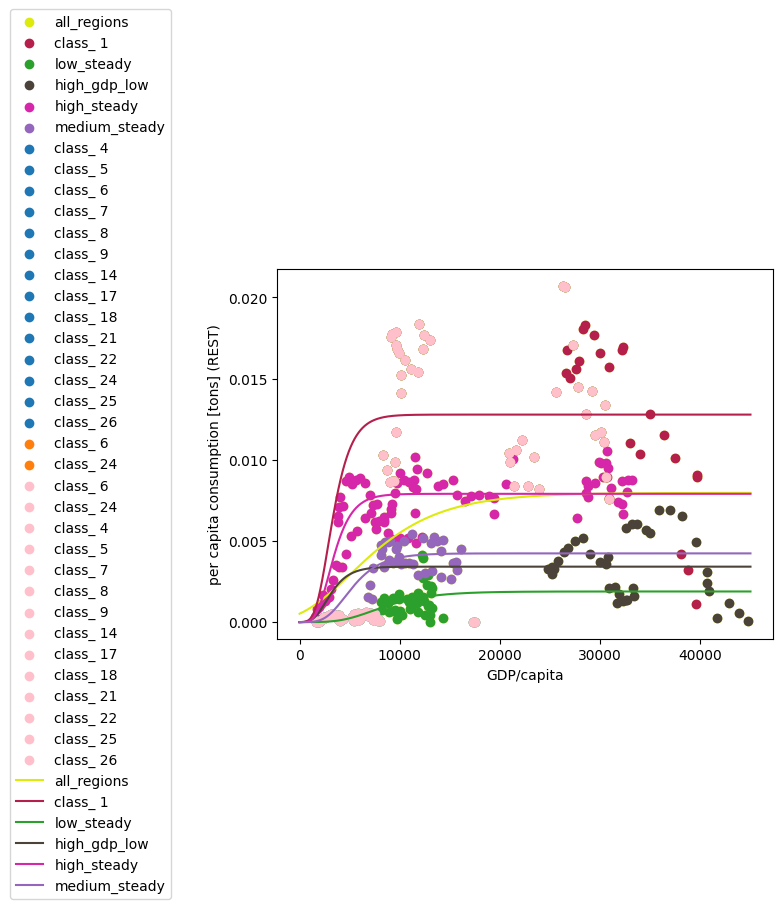

In [8]:
# Plot regression with GDP/cap on x axis and cons/cap on y axis

# Grouping of regions for fitting

color_rest = '#1f77b4'
color_class_1 = "#b41f4c"
color_spreaded = "#ff7f0e"
color_low_steady = "#2ca02c"
color_high_gdp_low = "#4b423a"
color_high_steady = "#d627aa"
color_medium_steady = "#9467bd"


color_dict_fits = {
    'class_ 1': color_class_1,
    'all_regions': "#dceb0c",  # Color for all region
    'low_steady': color_low_steady,
    'high_steady': color_high_steady,
    'medium_steady': color_medium_steady,
    'high_gdp_low': color_high_gdp_low
}



fig, ax = plt.subplots()             # Create a figure containing a single Axes.



for grouping, regions in copper.region_groups.items():
    if regions == "all_regions":
        continue
    ax.scatter(copper.gdp_pc[regions], 
                copper.cons_capita[regions], 
                label = grouping,
                color = color_dict_fits[grouping])


for region in rest:
    ax.scatter(copper.gdp_pc[region], 
                copper.cons_capita[region], 
                label = region,
                color = color_rest)
    

for region in spreaded:
    ax.scatter(copper.gdp_pc[region], 
               copper.cons_capita[region], 
               label = region,
               color = color_spreaded)


for region in exclude:
    ax.scatter(copper.gdp_pc[region], 
                copper.cons_capita[region], 
                label = region,
                color = "pink")

for grouping in copper_regions.keys():
    model = copper.model_groups[grouping][models_output_dict[copper.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 45000).reshape(-1, 1)),
            label = grouping, color = color_dict_fits[grouping])
    
# set ax limits
ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")
ax.legend(loc = 'right', bbox_to_anchor=(-0.2, 0.5))
    

In [9]:
copper.model_groups

{'all_regions': (<imagematerials.rest_of.regression_models_classes.Log_Log_Model at 0x174e6205940>,
  <imagematerials.rest_of.regression_models_classes.Log_Gauss_Saturate_Model at 0x174e6206ba0>),
 'class_ 1': (<imagematerials.rest_of.regression_models_classes.Log_Log_Model at 0x174e6127c50>,
  <imagematerials.rest_of.regression_models_classes.Log_Gauss_Saturate_Model at 0x174e62a07d0>),
 'low_steady': (<imagematerials.rest_of.regression_models_classes.Log_Log_Model at 0x174e62a0910>,
  <imagematerials.rest_of.regression_models_classes.Log_Gauss_Saturate_Model at 0x174e62a1450>),
 'high_gdp_low': (<imagematerials.rest_of.regression_models_classes.Log_Log_Model at 0x174e4bbf5c0>,
  <imagematerials.rest_of.regression_models_classes.Log_Gauss_Saturate_Model at 0x174e60dfce0>),
 'high_steady': (<imagematerials.rest_of.regression_models_classes.Log_Log_Model at 0x174e60dfe10>,
  <imagematerials.rest_of.regression_models_classes.Log_Gauss_Saturate_Model at 0x174e62b89d0>),
 'medium_steady': 

In [10]:
copper.project_on_total(all_regions_list_class[:-1])

In [11]:
copper.region_model_match["class_ 5"]._coefs

array([1.88831983e-03, 9.96970558e+00, 3.15045270e+00])